## Part - B Data Analysis & Testing

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")

In [3]:
data = pd.read_csv("public_health_dataset.csv")
data.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,RID00001,18-25,21,79,Female,East,Non-Smoker,Rarely,35.62,145.2,True,True,230.4,134.1,2022-04-17
1,RID00002,26-35,28,62,Male,West,Non-Smoker,Weekly,24.17,124.4,True,False,223.6,137.3,2022-05-24
2,RID00003,18-25,18,85,Female,West,Smoker,Daily,26.84,136.9,False,False,214.1,101.0,2023-06-28
3,RID00004,46-60,48,49,Other,East,Non-Smoker,Never,15.19,122.0,True,False,201.0,126.4,2022-01-26
4,RID00005,36-45,43,110,Other,South,Former Smoker,Never,40.63,109.5,False,False,186.0,71.3,2022-06-19


## Hypothesis 1: Smoking vs Diabetes 

Does smoking status affect diabetes prevalence ? 


H₀ (Null Hypothesis) :- Smoking status has no effect on diabetes prevalence

H₁ (Alternative Hypothesis) :- Smoking status affects diabetes prevalence

In [4]:
pd.crosstab(data["smoking_status"], data["diabetes"])

diabetes,False,True
smoking_status,,
Former Smoker,297,71
Non-Smoker,298,34
Smoker,241,59


## Hypothesis 2: Exercise Frequency vs BMI 

Does exercise frequency affect BMI ?

H₀ (Null Hypothesis): Exercise frequency has no effect on BMI

H₁ (Alternative Hypothesis): Exercise frequency affects BMI

In [5]:
data.groupby("exercise_frequency")["bmi"].describe()

,count,mean,std,min,25%,50%,75%,max
exercise_frequency,,,,,,,,
Daily,276.0,27.975217,8.271438,13.55,21.3675,27.770,33.3725,48.44
Never,275.0,28.789709,8.631491,12.71,22.1700,28.440,34.0550,51.94
Rarely,230.0,28.434783,8.006456,13.37,22.5250,27.435,33.8200,48.93
Weekly,219.0,28.269543,7.638905,13.03,22.7300,27.790,33.5750,51.31


## Task - 2 Confidence Interval 

In [6]:
age_mean = data["age"].mean()
age_sem = stats.sem(data["age"])
age_ci = stats.t.interval(0.95, len(data["age"])-1, loc=age_mean, scale=age_sem)

weight_mean = data["weight"].mean()
weight_sem = stats.sem(data["weight"])
weight_ci = stats.t.interval(0.95, len(data["weight"])-1, loc=weight_mean, scale=weight_sem)

print("Age 95% Confidence Interval:", age_ci)
print("Weight 95% Confidence Interval:", weight_ci)

Age 95% Confidence Interval: (np.float64(47.18595257867964), np.float64(49.49404742132037))
Weight 95% Confidence Interval: (np.float64(76.79290345385549), np.float64(79.1390965461445))


## Task - 3 One Sample T-test

In [7]:
t_stat, p_val = stats.ttest_1samp(data["bmi"], 25)

print("T-Statistic:", t_stat)
print("P-Value:", p_val)

if p_val < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

T-Statistic: 13.037389394064578
P-Value: 5.404720375843021e-36
Reject Null Hypothesis


## Task - 4 Z-test

In [8]:
sample_mean = data["age"].mean()
pop_mean = 40
std_dev = data["age"].std()
n = len(data["age"])

z_score = (sample_mean - pop_mean) / (std_dev / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print("Z-Score:", z_score)
print("P-Value:", p_value)

Z-Score: 14.181330405927731
P-Value: 0.0


## Task - 5 Independent T - test 

In [9]:
bmi_smokers = data[data["smoking_status"]=="Smoker"]["bmi"]
bmi_nonsmokers = data[data["smoking_status"]=="Non-Smoker"]["bmi"]

t_stat, p_val = stats.ttest_ind(bmi_smokers, bmi_nonsmokers)

print("T-Statistic:", t_stat)
print("P-Value:", p_val)

if p_val < 0.05:
    print("Significant BMI difference")
else:
    print("No significant BMI difference")

T-Statistic: -0.5583911764004881
P-Value: 0.5767756897489559
No significant BMI difference


## Task - 6 Chi-Square Test

In [10]:
table = pd.crosstab(data["smoking_status"], data["diabetes"])

chi2, p_val, dof, expected = stats.chi2_contingency(table)

print("Chi-Square Value:", chi2)
print("P-Value:", p_val)

if p_val < 0.05:
    print("Variables are related")
else:
    print("No relationship found")

Chi-Square Value: 13.767874091157793
P-Value: 0.0010241041530452322
Variables are related


## Task - 7 Anova Test

In [11]:
group1 = data[data["age_group"]=="18-25"]["bmi"]
group2 = data[data["age_group"]=="26-35"]["bmi"]
group3 = data[data["age_group"]=="36-45"]["bmi"]
group4 = data[data["age_group"]=="46-60"]["bmi"]
group5 = data[data["age_group"]=="60+"]["bmi"]

f_stat, p_val = stats.f_oneway(group1, group2, group3, group4, group5)

print("F-Statistic :", f_stat)
print("P-Value :", p_val)

if p_val < 0.05:
    print("BMI differs across age groups")
else:
    print("No significant difference")

F-Statistic : 2.274702867643033
P-Value : 0.05945733815251672
No significant difference


## Task - 8 Correlation 

In [12]:
correlation = data["age"].corr(data["bmi"])
print("Correlation:", correlation)

Correlation: 0.04679900305150936


## Task - 9 Covariance

In [13]:
covariance = data[["age","bmi"]].cov()
print("Covariance Matrix:\n", covariance)

Covariance Matrix:
             age        bmi
age  345.858258   7.112830
bmi    7.112830  66.790325


## Task - 10 Visualizations 

### Age Distribution :-

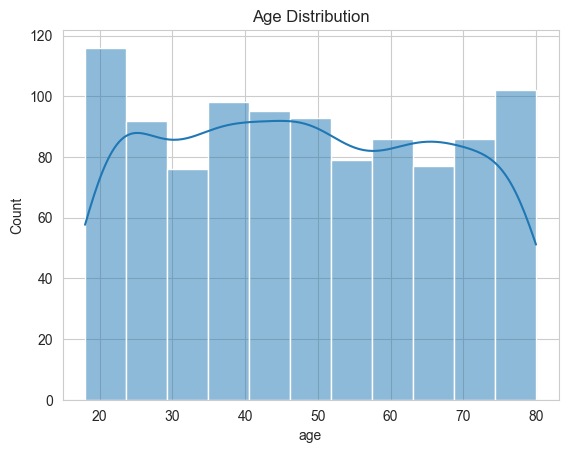

In [14]:
plt.figure()
sns.histplot(data["age"], kde=True)
plt.title("Age Distribution")
plt.show()

### BMI By Smoking Status

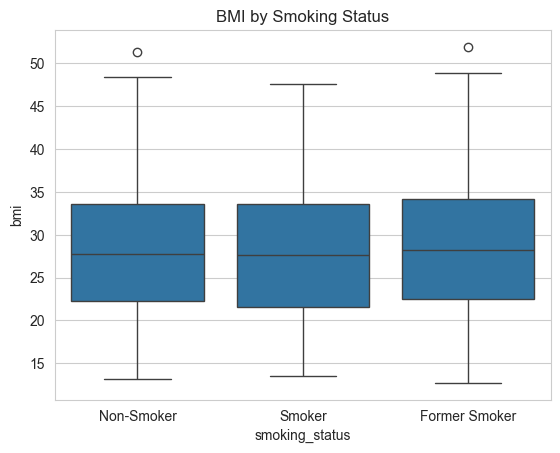

In [16]:
plt.figure()
sns.boxplot(x="smoking_status", y="bmi", data=data)
plt.title("BMI by Smoking Status")
plt.show()

### Correlation Heatmap

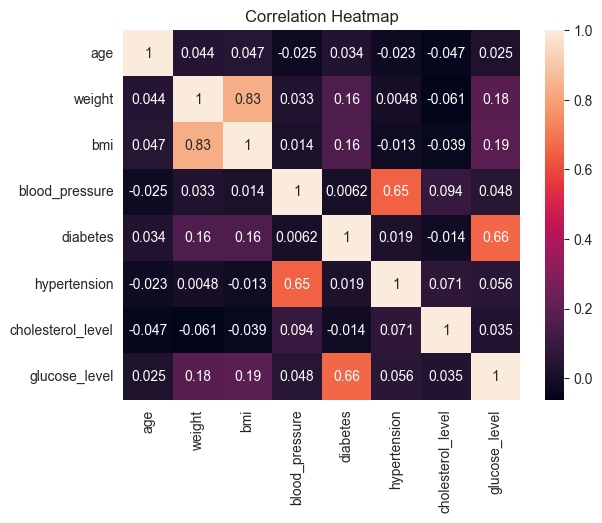

In [17]:
plt.figure()
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()